# Tools
- Tools in LangGraph are external functions or APIs that the LLM can call to perform specific tasks
- Tools extend the capability of an LLM
- Eg: LLM will not have the information of what happened today, so it will have an external tool which will connect to internet and then fetch the answers from there
- In graphs, all the tools are reprsented by an inbuilt node called Tool Node
- Tools condition
    - This is a prebuilt conditional edge function that helps your graph decide on whether the tool must invoke a tool or not
- Tools can be prebuilt(DuckDuckGoSearchRun) or custom tools
- Problem Statement:
    - Given the query the answer must be fetched from DuckDuckGo and then the result must be trimmed by using another custom tool for trimming


In [14]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_community.tools import DuckDuckGoSearchRun
from langchain.tools import tool

In [15]:
class State(TypedDict):
    query: str
    search_result: str
    final_answer: str

# Inbuilt tool

In [16]:
search_tool = DuckDuckGoSearchRun()


# Custom tool
- Use the decorator `@tool`
- You can specify the name and the description of the tool within the decorator i.e. @tool(name = "tool name", description="What the tool does")
- By default the description of the tool is picked up from the docStrings



In [17]:
@tool
def trim(text):
    """Trims the text"""
    return text[:300]

# Function defination

In [18]:
def search_node(state:State):
    query = state["query"]

    result = search_tool.invoke(query)
    
    return {"search_result": result}

def trim_node(state:State):
    text = state["search_result"]

    trimmed_resullt = trim.invoke({"text": text})
    return {"final_answer": trimmed_resullt}

# Build the graph

In [19]:
graph = StateGraph(State)

# Add nodes
graph.add_node("search", search_node)
graph.add_node("trim", trim_node)


# Adding edges
- If an edge must be created from START -> Node1 we use `graph.add_edge(START, "node1")`
- This can also be replaced by `graph.set_entry_point("node1")`. Both of these means the same

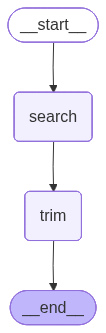

In [20]:
graph.set_entry_point("search")
graph.add_edge("search","trim")
graph.add_edge("trim", END)

workflow = graph.compile()
workflow

In [21]:
initial_state = {"query": "What is langGraph?"}

workflow.invoke(initial_state)

{'query': 'What is langGraph?',
 'search_result': 'Whatdoes all this information mean? The following example can offer a clearer understanding ofLangGraph: Think about these graph-based architectures ... WhatisLangGraph? ...LangGraphisa library for developing complex, stateful applications with Large Language Models (LLMs) that involve multiple ... WhatisLangGraph? ...LangGraphisa library built on top of Langchain thatisdesigned to facilitate the creation of cyclic graphs for large ... WhatisLangGraph? A Comprehensive Guide to Graph-Based Language Models ... Are you familiar with LangChain? Did you knowLangGraphisthe extension ... WhatisLangGraph? ...LangGraph’ s ability to produce ...LangGraphMemoryisa part of theLangGraphstructure that boosts language models.',
 'final_answer': 'Whatdoes all this information mean? The following example can offer a clearer understanding ofLangGraph: Think about these graph-based architectures ... WhatisLangGraph? ...LangGraphisa library for developing